In [1]:
# %matplotlib inline
%matplotlib widget
import matplotlib.pyplot as plt

from glob import glob

In [2]:
import numpy as np
import xarray as xr
import scipy

from pyxlma.lmalib.traversal import OneToManyTraversal

from tracerpaws.tracktimeseries import open_track_timeseries_dataset, track_polarimetry, add_track_durations, feature_distance_from

import pandas as pd

In [3]:
#timeseries_file = '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220807/timeseries_data_melt4900.nc'

path_to_tobac_Save = '/data/Houston/TRACER_TRACKING_STG/'
ts_pathstring_all_days = '{1}/tobac_Save_2022*/timeseries_data_melt*.nc'.format(None, path_to_tobac_Save)
ts_fns = sorted(glob(ts_pathstring_all_days))
ref_grid = '/data/Houston/TRACER_TRACKING_STG_firsttry/20220807/KHGX20220807_000004_V06_grid.nc'
for tsfn in ts_fns:
    tffn = '/'.join(tsfn.split('/')[:-1]) +'/Track_features_merges.nc'
    print(tsfn, tffn)

/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220602/timeseries_data_melt4400.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220602/Track_features_merges.nc
/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220604/timeseries_data_melt4500.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220604/Track_features_merges.nc
/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220617/timeseries_data_melt5000.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220617/Track_features_merges.nc
/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220622/timeseries_data_melt4700.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220622/Track_features_merges.nc
/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220702/timeseries_data_melt5000.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220702/Track_features_merges.nc
/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220706/timeseries_data_melt5000.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220706/Track_features_merges.nc
/data/Houston/TRACER_TRACKING_STG/

In [4]:
csapr_lon, csapr_lat = -95.283893, 29.531782
khgx_lat, khgx_lon = 29.4719, -95.0788
khgx_distance_km = 90.0

In [5]:
all_rows = []
for timeseries_file in ts_fns:
    track_file = '/'.join(timeseries_file.split('/')[:-1]) +'/Track_features_merges.nc'
    print(timeseries_file, track_file)
    combo = open_track_timeseries_dataset(track_file, timeseries_file, ref_grid)

    # This is copied from the toback_track_histograms script
    
    combo = feature_distance_from(combo, csapr_lon, csapr_lat, 'csapr')
    combo = feature_distance_from(combo, khgx_lon, khgx_lat, 'khgx')
    
    # Set up a prunable tree for the track,cell,feature dataset
    traversal = OneToManyTraversal(combo, ('track','cell','feature'), ('cell_parent_track_id', 'feature_parent_cell_id'))
    
    # Find tracks IDs with at least one feature within the specified range
    feature_in_range = (combo['feature_khgx_dist'] < (khgx_distance_km * 1000.0))
    reduced_track_ids = np.unique(combo[{'feature':feature_in_range}].feature_parent_track_id)
    combo = traversal.reduce_to_entities('track', reduced_track_ids)
    
    combo = add_track_durations(combo)

    track_dBZ_thresh = 35.0
    feature_is_bright = (combo['feature_maxrefl'] > track_dBZ_thresh)
    
    reduced_track_ids = np.unique(combo[{'feature':feature_is_bright}].feature_parent_track_id)
    traversal = OneToManyTraversal(combo, ('track','cell','feature'), ('cell_parent_track_id', 'feature_parent_cell_id'))
    combo = traversal.reduce_to_entities('track', reduced_track_ids)
    
    membership, counts = track_polarimetry(combo)
    this_date = track_file.split('/')[-2].replace('tobac_Save_','')
    counts['date']=this_date
    counts = counts.set_index(['date'])
    all_rows.append(counts)
    combo.close()

/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220602/timeseries_data_melt4400.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220602/Track_features_merges.nc


/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220604/timeseries_data_melt4500.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220604/Track_features_merges.nc


/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220617/timeseries_data_melt5000.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220617/Track_features_merges.nc


...

/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220915/timeseries_data_melt4900.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220915/Track_features_merges.nc


/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220917/timeseries_data_melt4700.nc /data/Houston/TRACER_TRACKING_STG/tobac_Save_20220917/Track_features_merges.nc


/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/ebruning/miniconda3/envs/lmatracer/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [6]:
# This DF actually shows feature level counts.

In [7]:
df = pd.concat(all_rows)
df['total'] = df.sum(axis=1)
column_renamer = dict((name, name.replace('track_has_', 'f_').replace('_only', '')) for name in df.columns)
df = df.rename(columns=column_renamer)
df

,f_zdr_kdp_ltg,f_zdr_kdp,f_zdr_ltg,f_zdr,f_nothing,f_kdp,f_kdp_ltg,f_ltg,total
date,,,,,,,,,
20220602,115,131,66,732,857,0,0,1,1902
20220604,22,72,8,329,413,5,0,3,852
20220617,17,9,46,312,1247,2,0,27,1660
20220622,38,125,33,480,1376,17,0,0,2069
20220702,58,56,49,515,1485,1,0,5,2169
20220706,46,43,2,158,339,3,0,0,591
20220712,142,58,51,358,615,1,0,1,1226
20220713,69,29,7,250,757,0,0,0,1112
20220714,123,92,11,366,968,0,0,1,1561


In [8]:
fraction_df = df.div(df.total, axis=0)
fraction_df

,f_zdr_kdp_ltg,f_zdr_kdp,f_zdr_ltg,f_zdr,f_nothing,f_kdp,f_kdp_ltg,f_ltg,total
date,,,,,,,,,
20220602,0.060463,0.068875,0.0347,0.384858,0.450578,0.0,0.0,0.000526,1.0
20220604,0.025822,0.084507,0.00939,0.38615,0.484742,0.005869,0.0,0.003521,1.0
20220617,0.010241,0.005422,0.027711,0.187952,0.751205,0.001205,0.0,0.016265,1.0
20220622,0.018366,0.060416,0.01595,0.231996,0.665056,0.008217,0.0,0.0,1.0
20220702,0.02674,0.025818,0.022591,0.237437,0.684647,0.000461,0.0,0.002305,1.0
20220706,0.077834,0.072758,0.003384,0.267343,0.573604,0.005076,0.0,0.0,1.0
20220712,0.115824,0.047308,0.041599,0.292007,0.501631,0.000816,0.0,0.000816,1.0
20220713,0.06205,0.026079,0.006295,0.22482,0.680755,0.0,0.0,0.0,1.0
20220714,0.078796,0.058937,0.007047,0.234465,0.620115,0.0,0.0,0.000641,1.0


In [32]:
track_df = pd.read_csv('./cases/track_count_varymelt.csv').set_index('date')
track_df

,zdr_kdp_ltg,zdr_kdp,zdr_ltg,zdr,nothing,kdp,kdp_ltg,ltg,total
date,,,,,,,,,
2022-06-02,24,30,1,62,59,0,0,0,176
2022-06-04,7,18,3,18,119,0,0,0,165
2022-06-17,5,1,17,38,58,0,0,0,119
2022-06-22,16,27,2,53,90,0,0,0,188
2022-07-02,25,13,9,65,157,0,0,0,269
2022-07-06,3,6,0,24,46,0,0,0,79
2022-07-12,15,6,2,35,152,0,0,0,210
2022-07-13,6,4,0,26,188,0,0,0,224
2022-07-14,25,24,1,55,160,0,0,0,265


In [9]:
track_fraction_df = pd.read_csv('./cases/track_fraction_varymelt.csv')#.set_index('date')

In [10]:
track_fraction_df['date'] = track_fraction_df['date'].map(lambda s: s.replace('-',''))

In [11]:
track_fraction_df = track_fraction_df.set_index('date')
track_fraction_df

,zdr_kdp_ltg,zdr_kdp,zdr_ltg,zdr,nothing,kdp,kdp_ltg,ltg,total
date,,,,,,,,,
20220602,0.136364,0.170455,0.005682,0.352273,0.335227,0.000000,0.0,0.000000,1.0
20220604,0.042424,0.109091,0.018182,0.109091,0.721212,0.000000,0.0,0.000000,1.0
20220617,0.042017,0.008403,0.142857,0.319328,0.487395,0.000000,0.0,0.000000,1.0
20220622,0.085106,0.143617,0.010638,0.281915,0.478723,0.000000,0.0,0.000000,1.0
20220702,0.092937,0.048327,0.033457,0.241636,0.583643,0.000000,0.0,0.000000,1.0
20220706,0.037975,0.075949,0.000000,0.303797,0.582278,0.000000,0.0,0.000000,1.0
20220712,0.071429,0.028571,0.009524,0.166667,0.723810,0.000000,0.0,0.000000,1.0
20220713,0.026786,0.017857,0.000000,0.116071,0.839286,0.000000,0.0,0.000000,1.0
20220714,0.094340,0.090566,0.003774,0.207547,0.603774,0.000000,0.0,0.000000,1.0


In [28]:
# Features
df_all_days = df.sum(axis=0)
fraction_df_all_days = df_all_days.div(df_all_days.total, axis=0)
fraction_df_all_days

f_zdr_kdp_ltg    0.034727
f_zdr_kdp        0.042107
f_zdr_ltg        0.017392
f_zdr            0.250212
f_nothing        0.652339
f_kdp            0.001386
f_kdp_ltg             0.0
f_ltg            0.001838
total                 1.0
dtype: object

In [34]:
df_all_days

f_zdr_kdp_ltg     1228
f_zdr_kdp         1489
f_zdr_ltg          615
f_zdr             8848
f_nothing        23068
f_kdp               49
f_kdp_ltg            0
f_ltg               65
total            35362
dtype: object

In [33]:
# Tracks
track_df_all_days = track_df.sum(axis=0)
track_fraction_df_all_days = track_df_all_days.div(track_df_all_days.total, axis=0)
track_fraction_df_all_days

zdr_kdp_ltg    0.046875
zdr_kdp        0.044204
zdr_ltg        0.009482
zdr            0.147569
nothing        0.751202
kdp            0.000534
kdp_ltg        0.000000
ltg            0.000134
total          1.000000
dtype: float64

===== zdr_kdp_ltg =====
LinregressResult(slope=0.18701203357640037, intercept=0.029566272722389403, rvalue=0.3089177482995863, pvalue=0.13295737829052381, stderr=0.12005598693124628, intercept_stderr=0.009545849947000983)

===== zdr_kdp =====
LinregressResult(slope=0.32776484050511273, intercept=0.026730790649727814, rvalue=0.6008234459975637, pvalue=0.0014931409067293047, stderr=0.09092970988586367, intercept_stderr=0.0061849425596697824)

===== zdr_ltg =====
LinregressResult(slope=0.17804170694637594, intercept=0.014696118993608258, rvalue=0.41451349604885945, pvalue=0.0393806592848949, stderr=0.08150441754656185, intercept_stderr=0.0027367839719250942)

===== zdr =====
LinregressResult(slope=0.3030203670204846, intercept=0.1954557155202506, rvalue=0.42339911498219834, pvalue=0.03494712165596686, stderr=0.13519447823777633, intercept_stderr=0.029044603016202385)

===== nothing =====
LinregressResult(slope=0.23615170194324328, intercept=0.4802543012604059, rvalue=0.4282202704139428, p

Text(0, 0.5, 'Feature Fraction')

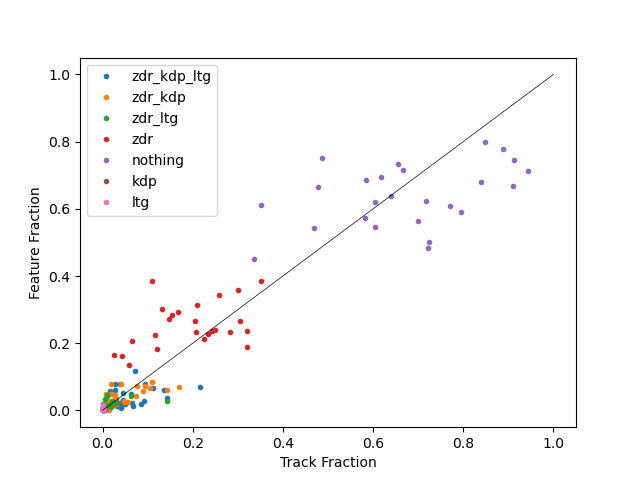

In [25]:
fig, ax = plt.subplots(1,1)
for track_type in ['zdr_kdp_ltg', 'zdr_kdp', 'zdr_ltg', 'zdr', 'nothing', 'kdp', 'ltg']:
    tf_data = track_fraction_df[track_type].astype(float)
    ff_data = fraction_df['f_'+track_type].astype(float)
    ax.plot(tf_data, ff_data, '.', label=track_type)

    print(f"===== {track_type} =====")
    result = scipy.stats.linregress(tf_data, ff_data)
    print(result)
    # result = scipy.stats.pearsonr(tf_data, ff_data)
    # print(result)
    # print(result.summary())
    print("")

ax.legend()
ax.plot([0,1],[0,1], 'k', lw=0.5)
ax.set_xlabel('Track Fraction')
ax.set_ylabel('Feature Fraction')

(-0.02, 0.4, -0.02, 0.4)

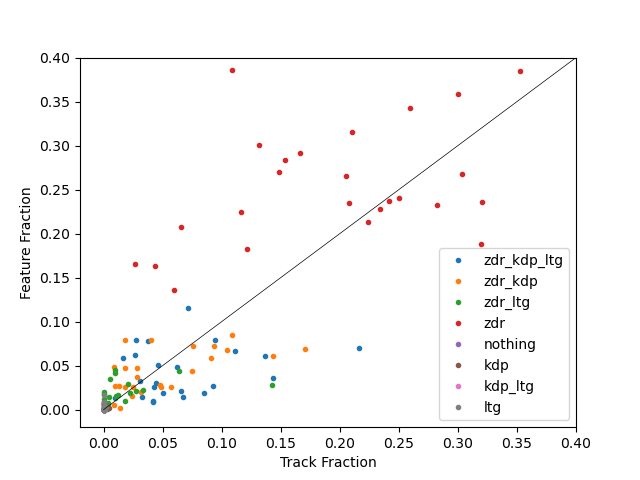

In [15]:
fig, ax = plt.subplots(1,1)
for track_type in ['zdr_kdp_ltg', 'zdr_kdp', 'zdr_ltg', 'zdr', 'nothing', 'kdp', 'kdp_ltg', 'ltg']:
    tf_data = track_fraction_df[track_type]
    ff_data = fraction_df['f_'+track_type]
    ax.plot(tf_data, ff_data, '.', label=track_type)
    
ax.legend()
ax.plot([0,1],[0,1], 'k', lw=0.5)
ax.set_xlabel('Track Fraction')
ax.set_ylabel('Feature Fraction')
ax.axis((-0.02, 0.4, -0.02, 0.4))

8-7 features:
ZKL 0.05055487053020962
ZK 0.036991368680641186
Z 0.3008631319358816
N 0.591861898890259
